In [1]:
import sys

In [2]:
sys.path.append('/tscc/lustre/restricted/alexandrov-ddn/users/ymadakamutil/microbiome_mechinterp/q2_mechinterp')

In [3]:
#!/usr/bin/env python3
"""
Transcriptomics Feature Engineering with VAEs
==============================================

This script demonstrates how to use the `q2_mechinterp` package to extract
interpretable features from RNA-seq gene expression data using Variational
Autoencoders and Sparse Autoencoders.

Overview:
1. Load and preprocess gene expression data
2. Train a VAE for dimensionality reduction
3. Train a Sparse Autoencoder on the latent space
4. Analyze gene importance
5. Evaluate features on downstream classification
6. Visualize results

Usage:
    python transcriptomics_example.py

Requirements:
    pip install q2-mechinterp[all]
"""

import numpy as np
import pandas as pd
import torch
from pathlib import Path

# q2_mechinterp imports
from q2_mechinterp.transcriptomics import TranscriptomicsVAE, TranscriptomicsDataProcessor
from q2_mechinterp.training import VAETrainer
from q2_mechinterp.extraction import FeatureExtractor
from q2_mechinterp.core.utils import get_device, set_seed
from q2_mechinterp.core.logging import StructuredLogger, timer, print_model_summary
from q2_mechinterp.visualization import (
    plot_training_curves,
    plot_latent_space,
    plot_feature_importance,
    plot_reconstruction_comparison,
)
from q2_mechinterp.evaluation import FeatureEvaluator

In [4]:
# Load RNA data - first column is sample ID
rna_df = pd.read_csv('/tscc/lustre/restricted/alexandrov-ddn/users/ymadakamutil/ImmuneHRD_data/rna_seq/TCGA_BRCA_RNA_filt.csv', index_col=0)
print(f"RNA data shape: {rna_df.shape}")
print(f"Sample IDs: {rna_df.index[:5].tolist()}")

RNA data shape: (848, 19962)
Sample IDs: ['TCGA-E9-A1RH', 'TCGA-C8-A26W', 'TCGA-AO-A0JJ', 'TCGA-BH-A0HO', 'TCGA-BH-A18F']


In [5]:
rna_df.shape

(848, 19962)

In [6]:
# Load HRD scores and set sample as index
hrd_score_df = pd.read_csv('/tscc/lustre/restricted/alexandrov-ddn/users/ymadakamutil/ImmuneHRD_data/HRDscores/merged_annot.csv')
hrd_score_df = hrd_score_df.set_index('sample')
print(f"HRD data shape: {hrd_score_df.shape}")
print(f"Sample IDs: {hrd_score_df.index[:5].tolist()}")

HRD data shape: (848, 70)
Sample IDs: ['TCGA-E9-A1RH', 'TCGA-C8-A26W', 'TCGA-AO-A0JJ', 'TCGA-BH-A0HO', 'TCGA-BH-A18F']


In [7]:
# Rename HRD_status to condition for the pipeline
hrd_score_df = hrd_score_df.rename(columns={'HRD_status': 'condition'})

# Align samples between RNA and HRD data
common_samples = rna_df.index.intersection(hrd_score_df.index)
print(f"Common samples: {len(common_samples)}")

rna_df = rna_df.loc[common_samples]
hrd_score_df = hrd_score_df.loc[common_samples]

print(f"RNA data shape after alignment: {rna_df.shape}")
print(f"HRD data shape after alignment: {hrd_score_df.shape}")

Common samples: 848
RNA data shape after alignment: (848, 19962)
HRD data shape after alignment: (848, 70)


In [8]:

def main():
    """Main function demonstrating the VAE feature extraction workflow."""

    # =========================================================================
    # Configuration
    # =========================================================================

    OUTPUT_DIR = Path("./tcga_brc_vae_out")
    OUTPUT_DIR.mkdir(exist_ok=True)

    set_seed(42)
    device = get_device()
    print(f"Using device: {device}")

    logger = StructuredLogger("transcriptomics_vae", log_dir=OUTPUT_DIR)

    # =========================================================================
    # 1. Load and Preprocess Data
    # =========================================================================

    print("\n" + "=" * 60)
    print("Step 1: Loading and Preprocessing Data")
    print("=" * 60)

    # Generate synthetic data for this example
    counts_df = rna_df
    metadata_df = hrd_score_df

    print(f"Generated data shape: {counts_df.shape}")
    print(f"Condition distribution:\n{metadata_df['condition'].value_counts()}")

    # Initialize processor
    processor = TranscriptomicsDataProcessor()
    processor.load_from_dataframe(
        expression_df=counts_df, metadata_df=metadata_df, gene_column=None
    )

    # Filter lowly expressed genes
    print("\nFiltering genes...")
    processor.filter_genes(
        min_counts=10,
        min_samples_pct=0.1,
        top_pct=0.10,
    )
    print(f"Genes after filtering: {processor.n_genes}")

    # Normalize counts (log1p transformation)
    processor.normalize(method="log1p")

    # Scale features
    processor.scale_features()

    # Prepare train/val/test splits
    train_loader, val_loader, test_loader = processor.prepare_datasets(
        batch_size=32,
        test_size=0.2,
        val_size=0.1,
        random_state=42,
        stratify_column="condition",
    )

    print(f"Training samples: {len(train_loader.dataset)}")
    if val_loader is not None:
        print(f"Validation samples: {len(val_loader.dataset)}")
    if test_loader is not None:
        print(f"Test samples: {len(test_loader.dataset)}")

    logger.log_params(
        {
            "n_samples": len(counts_df),
            "n_genes_original": counts_df.shape[1],
            "n_genes_filtered": processor.n_genes,
        }
    )

    # =========================================================================
    # 2. Train Variational Autoencoder
    # =========================================================================

    print("\n" + "=" * 60)
    print("Step 2: Training Variational Autoencoder")
    print("=" * 60)

    # Get processed data
    processed_data = processor.scaled_data
    n_features = processed_data.shape[1]

    # Create VAE model
    vae = TranscriptomicsVAE(
        input_dim=n_features,
        latent_dim=64,
        hidden_dims=[512, 256],
        dropout_rate=0.2,
        use_residual=False,
    )

    print_model_summary(vae)

    # Create trainer
    trainer = VAETrainer(
        model=vae,
        device=device,
        learning_rate=5e-4,
        weight_decay=1e-5,
        gradient_clip=1.0,
    )

    # Set up learning rate scheduler
    trainer.set_scheduler(scheduler_type="cosine", T_max=150)

    # Train with early stopping
    with timer("VAE Training"):
        train_losses, val_losses = trainer.train(
            train_loader,
            val_loader,
            epochs=150,
            beta=0.5,
            alpha=0.1,
            patience=20,
            verbose=10,
            save_path=None,
        )

    # Plot training curves
    fig = plot_training_curves(
        train_losses,
        val_losses,
        title="Transcriptomics VAE Training",
        save_path=OUTPUT_DIR / "training_curves.png",
    )

    # Save model
    torch.save(vae.state_dict(), OUTPUT_DIR / "transcriptomics_vae.pt")

    # =========================================================================
    # 3. Extract Latent Features
    # =========================================================================

    print("\n" + "=" * 60)
    print("Step 3: Extracting Latent Features")
    print("=" * 60)

    extractor = FeatureExtractor(vae, device)

    latent_features = extractor.get_latent_features(processed_data)
    print(f"Latent features shape: {latent_features.shape}")

    # Visualize latent space by condition
    conditions = metadata_df["condition"].values
    condition_encoder = {c: i for i, c in enumerate(np.unique(conditions))}
    encoded_conditions = np.array([condition_encoder[c] for c in conditions])

    fig = plot_latent_space(
        latent_features,
        labels=encoded_conditions,
        label_names=list(condition_encoder.keys()),
        method="pca",
        title="Transcriptomics VAE Latent Space (by Condition)",
        save_path=OUTPUT_DIR / "latent_space_condition.png",
    )

    # # Also visualize by batch to check for batch effects
    # batches = metadata_df["batch"].values
    # batch_encoder = {b: i for i, b in enumerate(np.unique(batches))}
    # encoded_batches = np.array([batch_encoder[b] for b in batches])

    # fig = plot_latent_space(
    #     latent_features,
    #     labels=encoded_batches,
    #     label_names=list(batch_encoder.keys()),
    #     method="pca",
    #     title="Transcriptomics VAE Latent Space (by Batch)",
    #     save_path=OUTPUT_DIR / "latent_space_batch.png",
    # )

    # =========================================================================
    # 4. Train Sparse Autoencoder
    # =========================================================================

    print("\n" + "=" * 60)
    print("Step 4: Training Sparse Autoencoder")
    print("=" * 60)

    with timer("Sparse AE Training"):
        sparse_losses = extractor.train_sparse_autoencoder(
            latent_features,
            sparse_multiplier=4,
            l1_reg=0.001,
            epochs=100,
            lr=5e-4,
            batch_size=32,
            verbose=10,
        )

    sparse_features = extractor.get_sparse_features(latent_features)
    print(f"Sparse features shape: {sparse_features.shape}")
    print(f"Sparsity: {(sparse_features == 0).mean():.1%}")

    # Save features
    np.save(OUTPUT_DIR / "latent_features.npy", latent_features)
    np.save(OUTPUT_DIR / "sparse_features.npy", sparse_features)

    # =========================================================================
    # 5. Gene Importance Analysis
    # =========================================================================

    print("\n" + "=" * 60)
    print("Step 5: Gene Importance Analysis")
    print("=" * 60)
    
    gene_names = processor.get_feature_names()
    print("Got Gene names!")
    print(f"Extractor attributes{extractor.vae_model.encoder_layers:}\n")
    importance_results = extractor.analyze_feature_importance(original_feature_names=gene_names)
    print("Got importance results!")
    if "importance_df" in importance_results:
        importance_df = importance_results["importance_df"]
        print("\nTop 15 most important genes:")
        print(importance_df.head(15)[["Feature", "Importance"]].to_string())

        fig = plot_feature_importance(
            importance_df,
            top_n=25,
            title="Top Genes by Importance",
            save_path=OUTPUT_DIR / "gene_importance.png",
        )

        importance_df.to_csv(OUTPUT_DIR / "gene_importance.csv", index=False)

    # =========================================================================
    # 6. Reconstruction Quality
    # =========================================================================

    print("\n" + "=" * 60)
    print("Step 6: Evaluating Reconstruction Quality")
    print("=" * 60)

    reconstructions = extractor.get_reconstruction(processed_data)

    from sklearn.metrics import mean_squared_error, r2_score

    mse = mean_squared_error(processed_data, reconstructions)
    r2 = r2_score(processed_data.flatten(), reconstructions.flatten())
    correlation = np.corrcoef(processed_data.flatten(), reconstructions.flatten())[0, 1]

    print(f"Reconstruction MSE: {mse:.4f}")
    print(f"Reconstruction R²: {r2:.4f}")
    print(f"Pearson correlation: {correlation:.4f}")

    fig = plot_reconstruction_comparison(
        original=processed_data,
        reconstructed=reconstructions,
        n_samples=3,
        n_features=50,
        title="Original vs Reconstructed Gene Expression",
        save_path=OUTPUT_DIR / "reconstruction_comparison.png",
    )

    # =========================================================================
    # 7. Downstream Task Evaluation
    # =========================================================================

    print("\n" + "=" * 60)
    print("Step 7: Evaluating Features on Downstream Classification")
    print("=" * 60)

    evaluator = FeatureEvaluator(task="classification", cv=5, scoring="accuracy", verbose=True)

    # Compare original vs learned features
    feature_sets = {
        "original_scaled": processed_data,
        "vae_latent": latent_features,
        "sparse_ae": sparse_features,
    }

    comparison_result = evaluator.compare_features(
        feature_sets=feature_sets,
        y=encoded_conditions,
        models=["logistic", "rf", "knn"],
        scale_features=True,
    )

    print("\nFeature Comparison Results:")
    print(comparison_result.results_df.to_string())

    comparison_result.results_df.to_csv(OUTPUT_DIR / "feature_comparison.csv", index=False)

    # =========================================================================
    # Summary
    # =========================================================================

    print("\n" + "=" * 60)
    print("Summary")
    print("=" * 60)

    print(f"\nAll outputs saved to: {OUTPUT_DIR.absolute()}")
    print("\nFiles created:")
    for f in sorted(OUTPUT_DIR.iterdir()):
        print(f"  - {f.name}")

    # Get best result
    results_df = comparison_result.results_df
    best_idx = results_df["mean_score"].idxmax()

    print(
        f"""
    Data:
      - Samples: {len(counts_df)}
      - Original genes: {counts_df.shape[1]}
      - Filtered genes: {processor.n_genes}

    VAE:
      - Latent dimension: 64
      - Final train loss: {train_losses[-1]:.4f}
      - Final val loss: {val_losses[-1] if val_losses else 'N/A':.4f}

    Sparse AE:
      - Sparse features: {sparse_features.shape[1]}
      - Sparsity: {(sparse_features == 0).mean():.1%}

    Reconstruction:
      - MSE: {mse:.4f}
      - R²: {r2:.4f}

    Best downstream performance:
      - Features: {results_df.loc[best_idx, 'feature_set']}
      - Model: {results_df.loc[best_idx, 'model_name']}
      - Accuracy: {results_df.loc[best_idx, 'mean_score']:.2%}
    """
    )


Using CUDA device: NVIDIA A100-PCIE-40GB
Using device: cuda
10:38:29 | INFO     | Initialized logger: transcriptomics_vae

Step 1: Loading and Preprocessing Data
Generated data shape: (848, 19962)
Condition distribution:
condition
0    645
1    203
Name: count, dtype: int64
Expression data shape: (848, 19962)
Metadata shape: (848, 70)

Filtering genes...
After min counts filter: 17773 genes
After min samples filter: 17731 genes
Filtered from 19962 to 1773 genes
Genes after filtering: 1773
Applied log1p transformation
Applied standard scaling
Train samples: 593
Val samples: 85
Test samples: 170
Training samples: 593
Validation samples: 85
Test samples: 170
10:38:29 | INFO     | Parameters: n_samples=848, n_genes_original=19962, n_genes_filtered=1773

Step 2: Training Variational Autoencoder

Model: TranscriptomicsVAE
Total parameters:     2,136,903
Trainable parameters: 2,136,903
Non-trainable:        0
Layer                          Type                     Params
---------------------

Training: 100%|██████████| 150/150 [00:25<00:00,  5.92it/s, train=0.7365, val=0.6253]


Training completed in 25.34 seconds
Loaded best model weights
VAE Training completed in 25.34 seconds
Saved figure to tcga_brc_vae_out/training_curves.png

Step 3: Extracting Latent Features
Latent features shape: (848, 64)
Saved figure to tcga_brc_vae_out/latent_space_condition.png

Step 4: Training Sparse Autoencoder
Training sparse autoencoder: 64 -> 256
Sparse AE Epoch 1: Loss: 1.204498
Sparse AE Epoch 10: Loss: 1.020245
Sparse AE Epoch 20: Loss: 1.000575
Sparse AE Epoch 30: Loss: 0.987516
Sparse AE Epoch 40: Loss: 0.980929
Sparse AE Epoch 50: Loss: 0.974680
Sparse AE Epoch 60: Loss: 0.971981
Sparse AE Epoch 70: Loss: 0.971464
Sparse AE Epoch 80: Loss: 0.971998
Sparse AE Epoch 90: Loss: 0.973808
Sparse AE Epoch 100: Loss: 0.977226
Sparse autoencoder training completed in 7.52s
Sparse AE Training completed in 7.52 seconds
Sparse features shape: (848, 256)
Sparsity: 0.0%

Step 5: Gene Importance Analysis
Got Gene names!
Extractor attributesModuleList(
  (0): Linear(in_features=1773, 

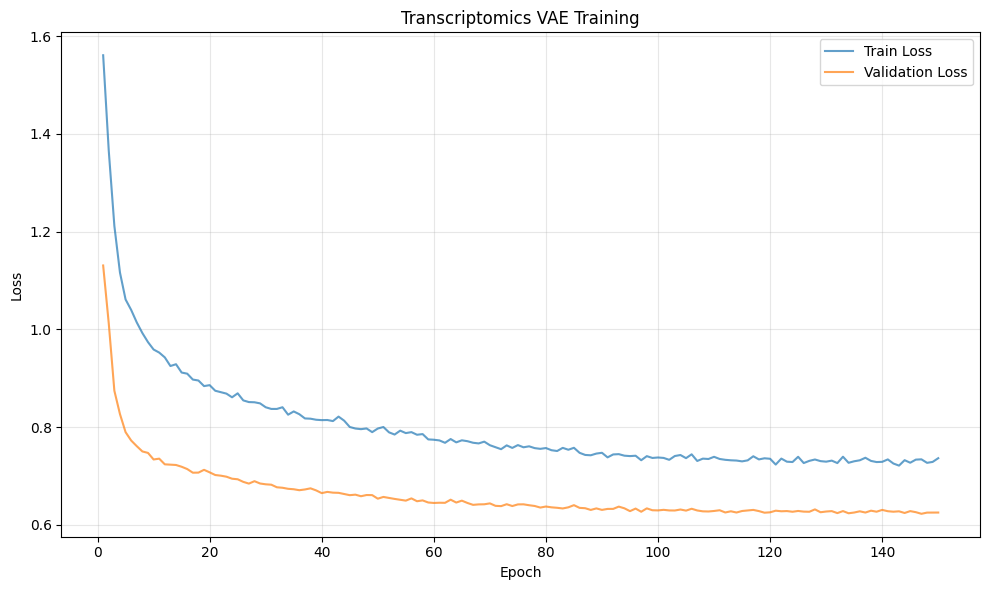

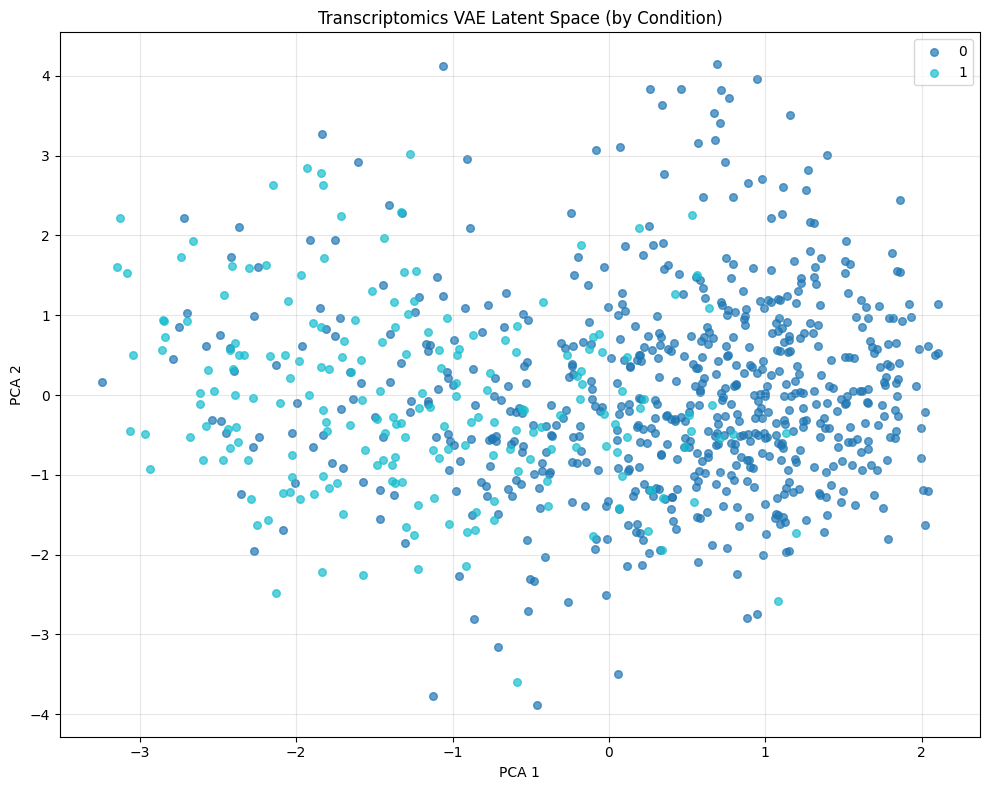

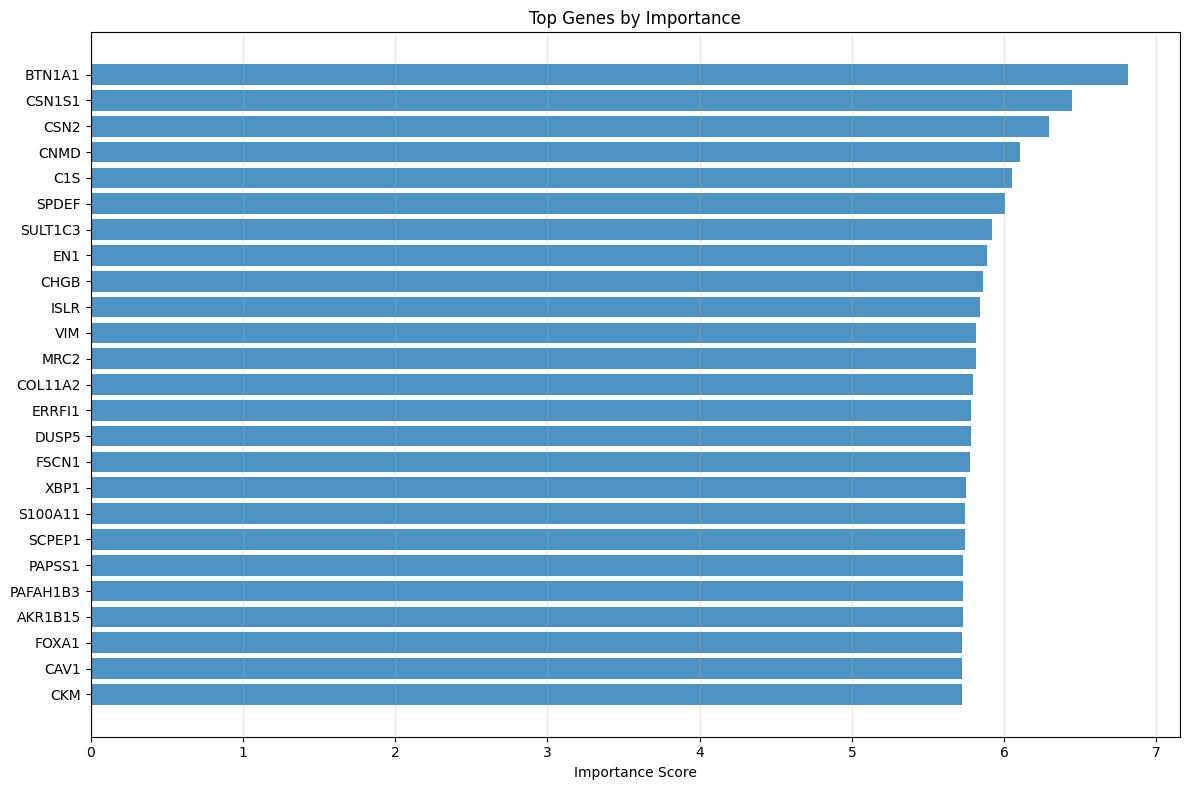

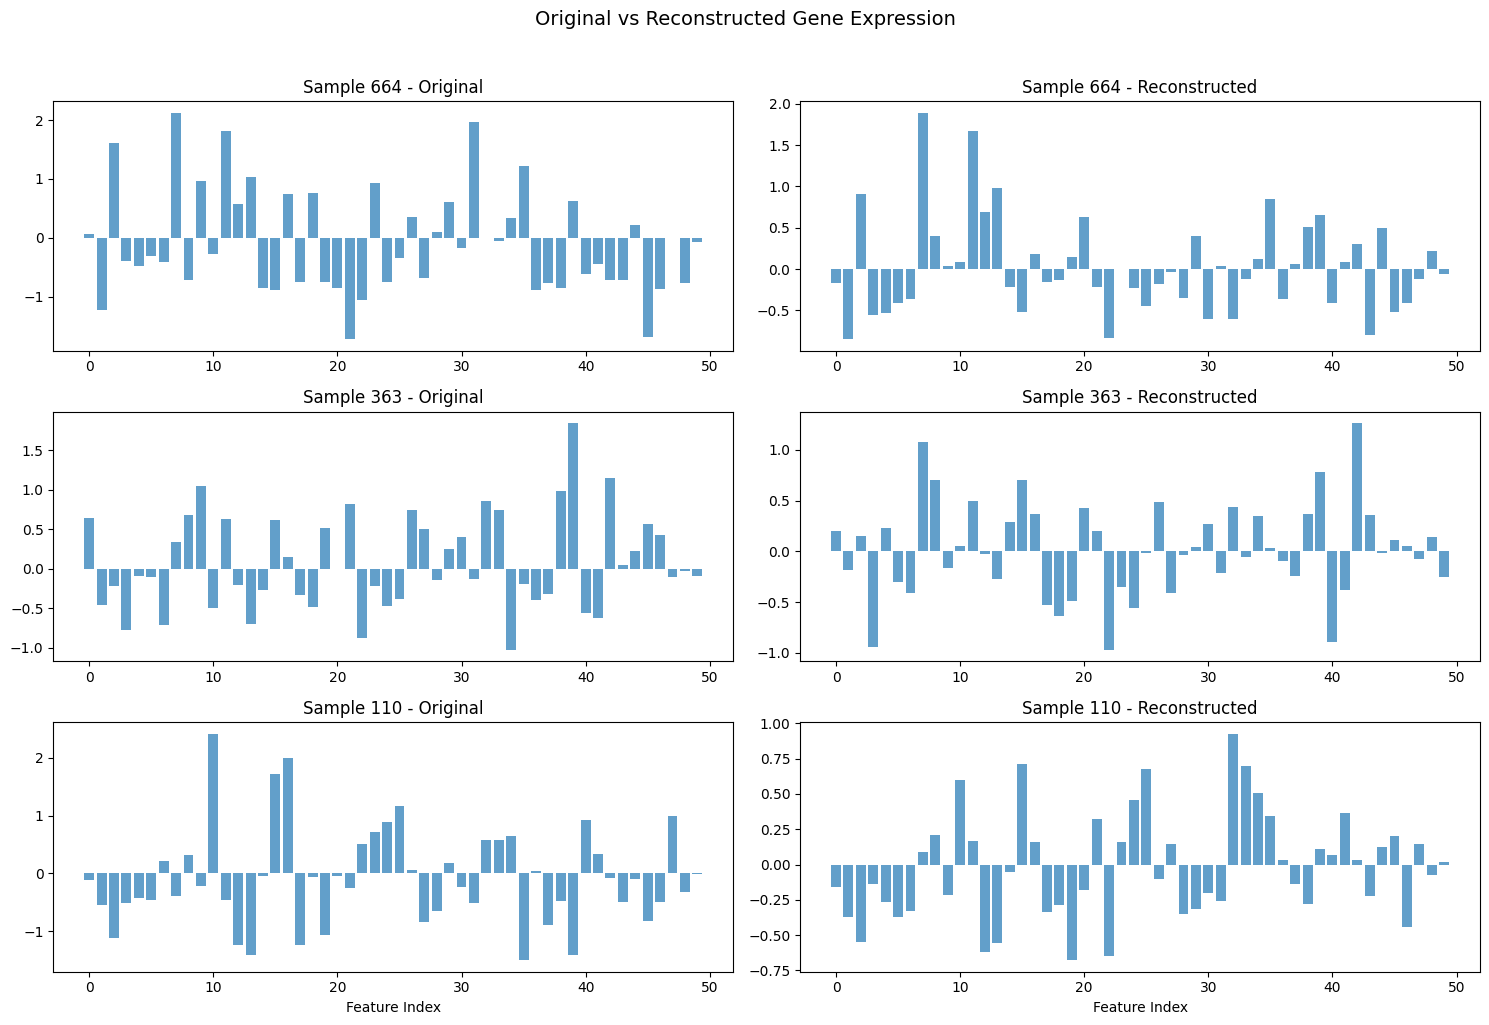

In [9]:
if __name__ == "__main__":
    main()